# Week 5: CTT 및 Guttman 구조 분석

## 학습 목표
고전검사이론(CTT) 및 Guttman 패턴 분석.

## 이론적 배경 (Mathematical Background)

Classical Test Theory:  

$$ X = T + E $$  

- X: Observed Score  
- T: True Score  
- E: Error

## 데이터 시뮬레이션 (Data Simulation)
Python을 사용하여 가상의 데이터를 생성합니다.

In [1]:
import numpy as np
import pandas as pd

# 20명의 학생, 10개의 문항에 대한 응답 (0 또는 1)
np.random.seed(0)
n_students = 20
n_items = 10

# 난이도가 다른 문항 생성 (확률 기반)
item_difficulties = np.linspace(0.9, 0.1, n_items)
responses = []
for p in item_difficulties:
    responses.append(np.random.binomial(1, p, n_students))

resp_df = pd.DataFrame(np.array(responses).T, columns=[f'Item_{i+1}' for i in range(n_items)])

## 결과 시뮬레이션 및 가시화 (Visualization)
생성된 데이터 또는 분석 결과를 시각화합니다.

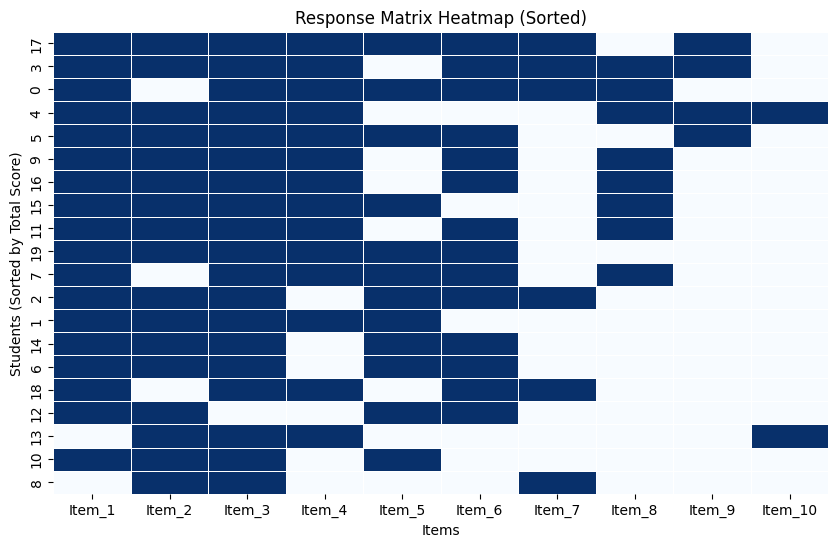

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 응답 패턴 Heatmap (Guttman scale 유사하게 정렬)
# 총점이 높은 학생 별, 정답률이 높은 문항 별 정렬
resp_df['Total'] = resp_df.sum(axis=1)
sorted_df = resp_df.sort_values(by='Total', ascending=False).drop('Total', axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(sorted_df, cmap='Blues', cbar=False, linewidths=.5)
plt.title('Response Matrix Heatmap (Sorted)')
plt.ylabel('Students (Sorted by Total Score)')
plt.xlabel('Items')
plt.show()

## CTT 통계량 및 Guttman 구조 분석
시뮬레이션 데이터를 바탕으로 고전검사이론(CTT)의 주요 통계량과 Guttman 척도의 성립 여부(재생산성 계수)를 계산합니다.

1.  **CTT 통계량**:
    *   **문항 난이도 ($p$)**: 정답률 (평균).
    *   **문항 변별도 ($r_{it}$)**: 문항-총점 간 상관계수 (Corrected Item-Total Correlation).
    *   **Cronbach's $\alpha$**: 검사 신뢰도.
2.  **Guttman 분석**:
    *   **재생산성 계수 (Coefficient of Reproducibility, CR)**: 응답 패턴이 Guttman 척도(완벽한 서열성)를 얼마나 잘 따르는지 나타내는 지표. 보통 0.9 이상이면 유효한 Guttman 척도로 봅니다.

In [3]:
# CTT Analysis
items = [col for col in resp_df.columns if col != 'Total']
item_data = resp_df[items]

# 1. Item Difficulty (p-value)
difficulty = item_data.mean()

# 2. Item Discrimination (Corrected Item-Total Correlation)
# Correlate each item with (Total Score - Item Score)
discrimination = {}
total_score = item_data.sum(axis=1)
for item in items:
    # Corrected Total Score = Total Score - Item Score (to avoid auto-correlation)
    corrected_total = total_score - item_data[item]
    # Handle case where item variance is 0 (constant response) to avoid NaN
    if item_data[item].std() == 0:
        discrimination[item] = 0.0
    else:
        discrimination[item] = item_data[item].corr(corrected_total)

# 3. Cronbach's Alpha
def cronbach_alpha(df):
    item_scores = df
    item_vars = item_scores.var(axis=0, ddof=1)
    total_scores = item_scores.sum(axis=1)
    n_items = df.shape[1]
    
    sum_item_vars = item_vars.sum()
    total_var = total_scores.var(ddof=1)
    
    # Avoid division by zero
    if total_var == 0:
        return 0.0
        
    alpha = (n_items / (n_items - 1)) * (1 - (sum_item_vars / total_var))
    return alpha

alpha = cronbach_alpha(item_data)

# Display CTT Results
ctt_df = pd.DataFrame({
    'Difficulty (p)': difficulty,
    'Discrimination (r_it)': pd.Series(discrimination)
})

print("=== Classical Test Theory (CTT) Statistics ===")
print(f"Cronbach's Alpha: {alpha:.3f}")
print("\nItem Statistics:")
print(ctt_df.round(3))


# Guttman Analysis
print("\n" + "="*40)
print("=== Guttman Scale Analysis ===")

# Sort items by difficulty (descending p-value -> Easy to Hard)
sorted_items = difficulty.sort_values(ascending=False).index
sorted_data = item_data[sorted_items]

# Calculate Errors (Goodenough-Edwards Method)
# Ideal pattern for a score of k: [1, 1, ..., 1, 0, 0, ..., 0] (k ones)
total_errors = 0
n_persons, n_items = sorted_data.shape

for idx, row in sorted_data.iterrows():
    score = int(row.sum())
    # Ideal pattern: 1 for first 'score' items, 0 for rest
    ideal_pattern = np.array([1]*score + [0]*(n_items - score))
    # Comparison
    observed_pattern = row.values
    # Count mismatches (simple error count)
    errors = np.abs(observed_pattern - ideal_pattern).sum()
    total_errors += errors

# Coefficient of Reproducibility (CR)
# CR = 1 - (Total Errors / Total Responses)
cr = 1 - (total_errors / (n_persons * n_items))

print(f"Sorted Items (Easy -> Hard): {list(sorted_items)}")
print(f"Total Response Count: {n_persons * n_items}")
print(f"Total Guttman Errors: {total_errors}")
print(f"Coefficient of Reproducibility (CR): {cr:.3f}")

if cr > 0.9:
    print("-> Result: This scale approximates a Guttman scale very well. (CR > 0.9)")
else:
    print("-> Result: Does not meet the strict Guttman scale criteria. (CR <= 0.9)")

=== Classical Test Theory (CTT) Statistics ===
Cronbach's Alpha: 0.055

Item Statistics:
         Difficulty (p)  Discrimination (r_it)
Item_1             0.90                  0.372
Item_2             0.85                 -0.348
Item_3             0.95                  0.137
Item_4             0.70                  0.299
Item_5             0.60                 -0.312
Item_6             0.70                  0.092
Item_7             0.30                 -0.119
Item_8             0.40                  0.143
Item_9             0.20                  0.466
Item_10            0.10                 -0.270

=== Guttman Scale Analysis ===
Sorted Items (Easy -> Hard): ['Item_3', 'Item_1', 'Item_2', 'Item_4', 'Item_6', 'Item_5', 'Item_8', 'Item_7', 'Item_9', 'Item_10']
Total Response Count: 200
Total Guttman Errors: 42
Coefficient of Reproducibility (CR): 0.790
-> Result: Does not meet the strict Guttman scale criteria. (CR <= 0.9)


### Cronbach's Alpha (크론바흐 알파)

#### 1. 수학적 정의 (Mathematical Definition)
Cronbach's alpha ($\alpha$)는 검사의 내적 일관성(Internal Consistency)을 측정하는 지표로, 다음과 같이 정의됩니다.

$$ \alpha = \frac{K}{K-1} \left( 1 - \frac{\sum_{i=1}^{K} \sigma^2_{Y_i}}{\sigma^2_X} \right) $$

where:
*   $K$: 검사 문항의 총 개수 (Number of test items)
*   $\sigma^2_{Y_i}$: $i$번째 문항 점수의 분산 (Variance of item $i$)
*   $\sigma^2_X$: 관측된 총점의 분산 (Variance of the observed total test scores)

#### 2. 의미 및 채택 이유 (Meaning & Adoption)
*   **의미**: 크론바흐 알파는 검사를 구성하는 문항들이 **"얼마나 동일한 개념(construct)을 측정하고 있는가"** 를 나타냅니다. 값은 이론적으로 $0$에서 $1$ 사이를 가지며, 높을수록 문항들 간의 상관관계가 높고 내적 일관성이 강함을 의미합니다.

#### 3. 심층 해석: 분산과 내적 일관성의 관계
사용자질문: 알파 값이 1이 되려면 **총점의 분산($\sigma^2_X$)이 개별 문항 분산의 합($\sum \sigma^2_{Y_i}$)보다 훨씬 커야** 합니다. 이것이 왜 "동일한 개념을 측정한다"는 의미가 될까요?

*   **총점의 분산 구성**:
    총점 $X = \sum Y_i$의 분산은 다음과 같이 전개됩니다.
    $$ \sigma^2_X = \sum \sigma^2_{Y_i} + \sum_{i \ne j} \text{Cov}(Y_i, Y_j) $$
    즉, **(개별 문항 분산의 합) + (문항 간 공분산의 합)** 입니다.

*   **알파 값이 높아지는 경우**:
    알파 값이 높으려면 $\frac{\sum \sigma^2_{Y_i}}{\sigma^2_X}$ 가 작아져야 하고, 이는 분모인 $\sigma^2_X$가 분자인 $\sum \sigma^2_{Y_i}$보다 월등히 커야 함을 의미합니다.
    위 식에서 $\sigma^2_X$가 $\sum \sigma^2_{Y_i}$보다 커지려면, 뒤에 더해지는 **공분산 항($\sum \text{Cov}(Y_i, Y_j)$)** 이 매우 큰 양수(+)여야 합니다.

*   **결론**:
    문항 간 공분산이 크다는 것은 **"한 문항에서 높은 점수를 받은 사람이 다른 문항에서도 높은 점수를 받는다"** 는 것을 의미합니다.
    즉 모든 문항들이 서로 강한 양의 상관관계를 가지고 같이 움직일 때(동일한 개념을 측정할 때), 공분산 합이 커져서 총점 분산이 극대화되고, 결과적으로 알파 값이 1에 가까워지게 됩니다. 이것이 곧 **내적 일관성**의 통계적 의미입니다.

### Cronbach's Alpha가 낮은 이유에 대한 고찰

위의 시뮬레이션 결과에서 Cronbach's Alpha 값이 매우 낮게(예: 0.1 미만) 나타나는 이유는 데이터 생성 방식에 있습니다.

#### Cronbach's Alpha Formula
$$ \alpha = \frac{K}{K-1} \left( 1 - \frac{\sum_{i=1}^{K} \sigma^2_{Y_i}}{\sigma^2_X} \right) $$

*   $K$: 문항 수
*   $\sigma^2_{Y_i}$: 각 문항의 점수 분산
*   $\sigma^2_X$: 총점의 분산

현재의 시뮬레이션 코드(`np.random.binomial(1, p, n_students)`)는 각 문항 생성 시 **학생들의 능력(Ability)을 고려하지 않고** 오직 문항의 난이도 확률에 따라 **독립적으로** 정답 여부를 결정했습니다.
이로 인해 문항 간 공분산(Covariance)이 거의 0이 되어, 총점의 분산 $\sigma^2_X$가 개별 문항 분산의 합 $\sum \sigma^2_{Y_i}$과 거의 비슷해집니다. 따라서 수식의 괄호 안 부분이 0에 가까워져 $\alpha$ 값이 매우 낮게 산출된 것입니다.

신뢰도를 높이려면 학생별 능력치(`theta`)를 설정하고, `theta`가 높을수록 모든 문항의 정답 확률이 높아지도록 데이터를 생성해야 합니다 (예: IRT 모형 기반 시뮬레이션).

#### Coefficient of Reproducibility (CR) Formula
$$ CR = 1 - \frac{\text{Total Errors}}{\text{Total Responses}} = 1 - \frac{\sum e}{N \times K} $$
*   $e$: Guttman 오차 (이상적인 패턴과의 불일치 수)
*   $N$: 학생 수
*   $K$: 문항 수

In [7]:
print("=== Improved Simulation with Student Ability (Theta) ===")

np.random.seed(42)

# 1. 능력치(theta)를 고려한 데이터 생성
# Student Ability: Normal(0, 1)
theta = np.random.normal(0, 1, n_students)

# Item Difficulty (beta): linspace(-2, 2)
# 문항 난이도를 확률이 아닌 로짓 스케일(beta)로 정의해야 IRT 모형과 유사해집니다.
beta = np.linspace(-2, 2, n_items)

new_responses = []
for i in range(n_items):
    # Rasch Model Probability: P = 1 / (1 + exp(-(theta - beta)))
    prob = 1 / (1 + np.exp(-(theta - beta[i])))
    new_responses.append(np.random.binomial(1, prob))

new_resp_df = pd.DataFrame(np.array(new_responses).T, columns=[f'Item_{i+1}' for i in range(n_items)])


# 2. CTT Analysis (New Data)
new_items = new_resp_df.columns
new_item_data = new_resp_df

# Difficulty
new_difficulty = new_item_data.mean()

# Discrimination
new_discrimination = {}
new_total_score = new_item_data.sum(axis=1)
for item in new_items:
    corrected_total = new_total_score - new_item_data[item]
    if new_item_data[item].std() == 0:
        new_discrimination[item] = 0.0
    else:
        new_discrimination[item] = new_item_data[item].corr(corrected_total)

# Cronbach's Alpha
new_alpha = cronbach_alpha(new_item_data)

new_ctt_df = pd.DataFrame({
    'Difficulty (p)': new_difficulty,
    'Discrimination (r_it)': pd.Series(new_discrimination)
})

print(f"\n[Improved Data] Cronbach's Alpha: {new_alpha:.3f}")
print("-> 능력치(Theta)를 반영하자 내적 일관성(신뢰도)이 크게 상승함을 확인할 수 있습니다.")
print("\n[Improved Data] Item Statistics:")
print(new_ctt_df.round(3))


# 3. Guttman Analysis (New Data)
print("\n" + "="*40)
print("=== Guttman Scale Analysis (Improved Data) ===")

sorted_items_new = new_difficulty.sort_values(ascending=False).index
sorted_data_new = new_item_data[sorted_items_new]

total_errors_new = 0
for idx, row in sorted_data_new.iterrows():
    score = int(row.sum())
    ideal_pattern = np.array([1]*score + [0]*(n_items - score))
    observed_pattern = row.values
    errors = np.abs(observed_pattern - ideal_pattern).sum()
    total_errors_new += errors

cr_new = 1 - (total_errors_new / (n_persons * n_items))

print(f"Total Guttman Errors: {total_errors_new}")
print(f"Coefficient of Reproducibility (CR): {cr_new:.3f}")

if cr_new > 0.9:
    print("-> Result: CR > 0.9 (Valid Guttman Scale)")
else:
    print("-> Result: CR <= 0.9 (Not strictly Guttman)")

=== Improved Simulation with Student Ability (Theta) ===

[Improved Data] Cronbach's Alpha: 0.660
-> 능력치(Theta)를 반영하자 내적 일관성(신뢰도)이 크게 상승함을 확인할 수 있습니다.

[Improved Data] Item Statistics:
         Difficulty (p)  Discrimination (r_it)
Item_1             0.80                  0.323
Item_2             0.65                  0.257
Item_3             0.65                  0.491
Item_4             0.60                  0.485
Item_5             0.50                  0.172
Item_6             0.40                  0.069
Item_7             0.30                  0.497
Item_8             0.15                  0.161
Item_9             0.25                  0.511
Item_10            0.05                  0.409

=== Guttman Scale Analysis (Improved Data) ===
Total Guttman Errors: 46
Coefficient of Reproducibility (CR): 0.770
-> Result: CR <= 0.9 (Not strictly Guttman)


### Guttman 척도와 재생산성 계수(CR)가 낮은 이유

두 번째 시뮬레이션(Improved Data)에서 능력치($\theta$)를 반영했음에도 불구하고, 재생산성 계수(CR)가 Guttman 척도의 기준인 0.9에 미치지 못하거나 낮게 나오는 경우가 많습니다. 그 이유는 **확률적 모형(Probabilistic Model)** 과 **결정적 모형(Deterministic Model)** 의 차이 때문입니다.

1.  **Guttman 척도의 가정 (결정적 모형)**:
    *   Guttman 척도는 **완벽한 서열성**을 가정합니다.
    *   즉, 어떤 학생의 능력이 문항의 난이도보다 높다면 무조건 맞추고($P=1$), 낮다면 무조건 틀려야($P=0$) 합니다.
    *   이상적인 패턴: `1, 1, 1, 0, 0` (중간에 0이 섞이거나 다시 1이 나오면 안 됨)

2.  **데이터 생성 모형 (확률적 모형 - Rasch/IRT)**:
    *   우리가 데이터를 생성할 때 사용한 Rasch 모형은 확률적입니다.
    *   $P(\theta) = \frac{1}{1 + e^{-(\theta - \beta)}}$
    *   능력이 난이도보다 월등히 높아도(예: $\theta - \beta = 2$), 정답 확률은 약 88%일 뿐 100%가 아닙니다. 즉, **실수로 틀릴 확률**이 항상 존재합니다.
    *   반대로 능력이 낮아도 **운으로 맞출 확률**이 존재합니다.

**결론**:
우리가 생성한 데이터는 현실 세계의 불확실성을 반영한 **확률적 로지스틱 모형**을 따르기 때문에, 오차 없이 완벽하게 서열이 지켜지는 **결정적 Guttman 모형**과는 필연적으로 차이가 발생합니다.

---

### 왜 "재생산성(Reproducibility)"이라고 부르는가?
**Coefficient of Reproducibility (CR)** 이라는 이름은 Guttman 척도의 핵심 특성에서 유래합니다.

*   **재생산 가능성**: 만약 완벽한 Guttman 척도(CR=1)라면, 학생의 **총점(Total Score)** 만 알면 그 학생이 **어떤 문항을 맞추고 어떤 문항을 틀렸는지 완벽하게 복원(Reproduce)할 수 있습니다.**
    *   예: 총점이 3점이면, 가장 쉬운 3문제는 맞추고($1,1,1$) 나머지는 모두 틀렸음($0,0...$)을 100% 확신할 수 있습니다.
*   즉, **"총점 하나만으로(오로지 총점 정보만으로) 원래의 응답 패턴 전체를 얼마나 정확하게 다시 만들어낼(Reproduce) 수 있는가?"** 를 측정하기 때문에 **재생산성 계수**라고 부릅니다.
*   CR 값이 낮다는 것은 총점만으로는 개별 문항의 정답 여부를 정확히 예측(복원)하기 어렵다는 뜻입니다.